In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import t

In [5]:
# Experimental data
xdata = np.array([0.1, 0.15, 0.25, 0.5, 0.75, 1.0, 1.5, 3.0])
mu = np.array([0.24, 0.27, 0.34, 0.35, 0.35, 0.34, 0.33, 0.22])

In [6]:
# CURVEFIT: nonlinear parameter estimation
def model_func(x, mu_max, km, kl):
    return mu_max*x/(km + x + kl*x**2)

initial_guess = [1.0, 1.0, 1.0]
params, pcov,_,mesg,_ = curve_fit(model_func, xdata=xdata, ydata=mu, p0=initial_guess, full_output=True)
print("- Convergence message:", mesg)

# Calculation of confidence intervals
n = len(mu)  # number of experimental data points
p = len(params)  # number of parameters

# Degrees of freedom
df = max(0, n - p)

# Confidence interval and Student's t distribution for a given alpha
alpha = 0.05
t_value = t.ppf(1 - alpha/2, df)  # t-value for a given alpha and degrees of freedom

# Calculation of standard error and confidence intervals
perr = np.sqrt(np.diag(pcov))
ci = t_value * perr

print("- Results obtained using nonlinear regression (curve_fit):")
mu_max = params[0]
km = params[1]
kl = params[2]
print(f"mu_max = {mu_max:.3f} ± {ci[0]:.3f}")
print(f"km = {km:.3f} ± {ci[1]:.3f}")
print(f"kl = {kl:.3f} ± {ci[2]:.3f}")

# Calculation of the squared error between model and data (SSE)
mu_pred = model_func(xdata, *params)
sse = np.sum((mu - mu_pred)**2)
print(f"Error (SSE) = {round(sse,5)}")

- Convergence message: Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
- Results obtained using nonlinear regression (curve_fit):
mu_max = 0.513 ± 0.101
km = 0.115 ± 0.059
kl = 0.390 ± 0.215
Error (SSE) = 0.00099


In [7]:
# Plotting the 95% confidence intervals
x_range = xdata  # For a smoother curve, use: np.linspace(min(xdata), max(xdata), 400)
mu_pred = model_func(x_range, *params)

# Jacobian calculation for this problem
def jacobian(x, mu_max, km, kl):
    J = np.empty((len(x), len(params)))
    J[:, 0] = x/(km + x + kl * x**2)  # Partial derivative with respect to mu_max
    J[:, 1] = -(mu_max*x)/(km + x + kl*x**2)**2  # Partial derivative with respect to km
    J[:, 2] = -(mu_max*x**2)/(km + x + kl*x**2)**2  # Partial derivative with respect to kl
    return J

J = jacobian(x_range, *params)
sigma_mu = np.sqrt(np.sum((J @ pcov)*J, axis=1))  # Equivalent to np.sqrt(np.diag(J @ pcov @ J.T)) but faster
mu_upper = mu_pred + t_value * sigma_mu
mu_lower = mu_pred - t_value * sigma_mu

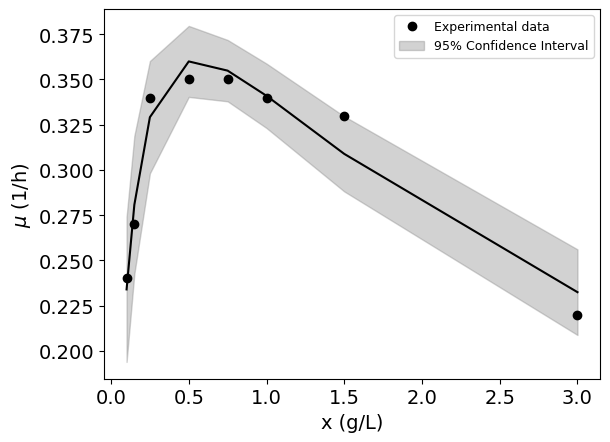

In [8]:
# Plotting the results
plt.plot(xdata, mu, 'ko', label='Experimental data')
plt.plot(xdata, mu_pred, 'k-')
plt.xlabel('x (g/L)', fontsize=14)
plt.ylabel('$\\mu$ (1/h)', fontsize=14)
plt.fill_between(x_range, mu_lower, mu_upper,
                 color='gray', alpha=0.35,
                 label='95% Confidence Interval')
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=9)

plt.show()